In [12]:
! pip install torch

In [13]:
import torch
print(torch.cuda.is_available())

True


In [14]:
import os
os.listdir()

['.config', 'robot.png', 'lib.py', '__pycache__', 'sample_data']

In [15]:
!pip install -qqq git+https://github.com/danoneata/chalk@srush-patch-1
!wget -q https://github.com/srush/GPU-Puzzles/raw/main/robot.png https://github.com/srush/GPU-Puzzles/raw/main/lib.py

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [16]:
import numba
import numpy as np
import warnings
from lib import CudaProblem, Coord

In [17]:
warnings.filterwarnings(
    action="ignore", category=numba.NumbaPerformanceWarning, module="numba"
)

# Map
 
   Score (Max Per Thread):
   |  Global Reads | Global Writes |  Shared Reads | Shared Writes |
   |             1 |             1 |             0 |             0 | 



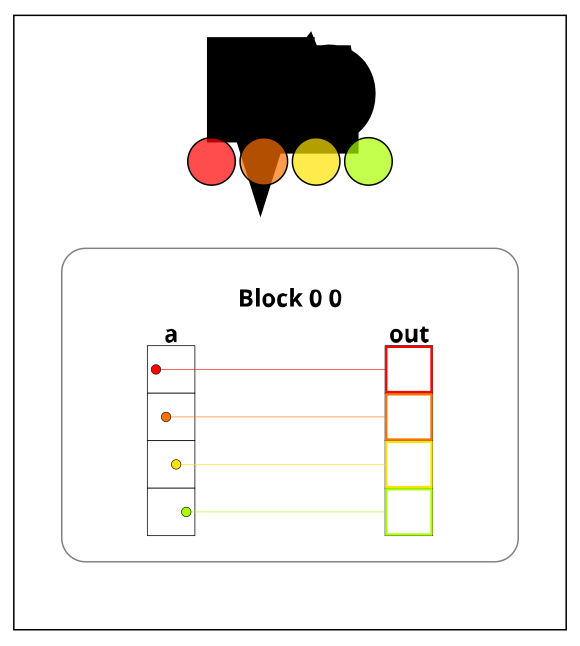

In [22]:
def map_spec(a):
    return a+10

def  map_test(cuda):
    def call(out, a) -> None:
        local_i=cuda.threadIdx.x
        out[local_i]=a[local_i]+10
    return call

SIZE = 4
out = np.zeros((SIZE,))
a = np.arange(SIZE)
problem = CudaProblem(
    "Map", map_test, [a], out, threadsperblock=Coord(SIZE, 1), spec=map_spec
)
problem.show()
